# Exam Project

Import and set magics:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size':14})

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
from SolowModel import SolowModelClass
from PortfolioModel import PortfolioModelClass
from states import STATES, REGION

## Problem 1

### Question 1.a

## Problem 2

### Question 2.a

## Problem 3: A portfolio with a risky and a safe asset

### Question 1

1. Draw $\varepsilon_t$ for all periods and all portfolios in one array of shape $(N,T)$ using the seed given, and compute $R_t$.
2. Report the mean and the standard deviation of $\log R_t$ across all the draws and compare them with $\mu$ and $\sigma$. Report the mean of $R_t$ and compare it with $\exp\left(\mu+\tfrac{1}{2}\sigma^2\right)$.
3. Make a figure with two panels: i) a histogram of $R_t$, and ii) the value of 1 invested in the risky asset in period 0 for 20 of the portfolios, together with the same for the safe asset. Use a logarithmic scale on the y-axis in panel ii).

In [2]:
# a. setup
model = PortfolioModelClass()
par = model.par
print(model)

# b. draw the gross return on the risky asset in all periods and all portfolios
R = model.draw_returns()
print(f'\nshape of R: {R.shape} = (N,T) = ({par.N:,},{par.T})')

# c. the moments of the log return
log_R = np.log(R)
print(f'\nmean of log(R) = {log_R.mean():.6f}   vs. mu    = {par.mu:.6f}')
print(f'std  of log(R) = {log_R.std():.6f}   vs. sigma = {par.sigma:.6f}')

# d. the mean of the gross return
print(f'\nmean of R      = {R.mean():.6f}   vs. exp(mu+0.5*sigma^2) = {np.exp(par.mu+0.5*par.sigma**2):.6f}')
print(f'                            vs. exp(mu)             = {np.exp(par.mu):.6f}')

# e. the risky asset compared with the safe asset
print(f'\nsafe gross return, exp(r) = {np.exp(par.r):.6f}')
print(f'share of draws with R < exp(r) = {np.mean(R < np.exp(par.r)):.4f}')

Portfolio model with:
  mu    = 0.0500, sigma = 0.2000, r = 0.0100
  theta_star = 0.5000, Delta = 0.1000, tau = 0.0100
  gamma = 3.0000 (relative risk aversion)
  W0 = 1.00, T = 40, N = 50,000, seed = 2026

shape of R: (50000, 40) = (N,T) = (50,000,40)

mean of log(R) = 0.050023   vs. mu    = 0.050000
std  of log(R) = 0.199965   vs. sigma = 0.200000

mean of R      = 1.072527   vs. exp(mu+0.5*sigma^2) = 1.072508
                            vs. exp(mu)             = 1.051271

safe gross return, exp(r) = 1.010050
share of draws with R < exp(r) = 0.4208


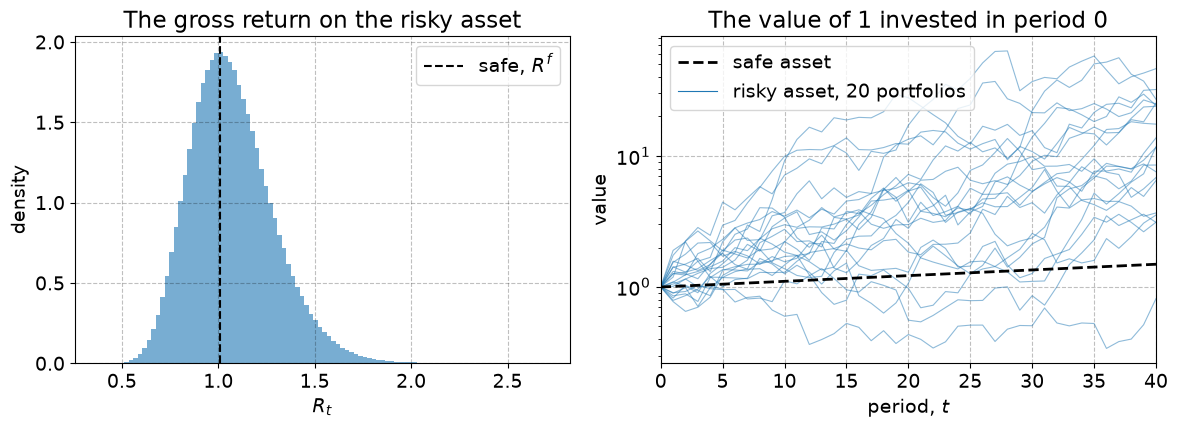

In [3]:
def plot_returns(model,R,n_show=20):

    par = model.par

    # a. the value of 1 invested in period 0, one period at a time
    V_risky = np.ones((n_show,par.T+1))
    for t in range(par.T):
        V_risky[:,t+1] = V_risky[:,t]*R[:n_show,t]

    V_safe = np.ones(par.T+1)
    for t in range(par.T):
        V_safe[t+1] = V_safe[t]*np.exp(par.r)

    fig = plt.figure(figsize=(12,4.5))

    # b. the distribution of the gross return
    ax = fig.add_subplot(1,2,1)
    ax.hist(R.reshape(par.N*par.T),bins=100,density=True,color=colors[0],alpha=0.60)
    ax.axvline(np.exp(par.r),ls='--',lw=1.5,color='black',label='safe, $R^f$')
    ax.set_title('The gross return on the risky asset')
    ax.set_xlabel('$R_t$')
    ax.set_ylabel('density')
    ax.legend()

    # c. the value of 1 invested in period 0
    ax = fig.add_subplot(1,2,2)
    ax.plot(V_risky.T,lw=0.8,color=colors[0],alpha=0.50)
    ax.plot(V_safe,ls='--',lw=2,color='black',label='safe asset')
    ax.plot([],[],lw=0.8,color=colors[0],label=f'risky asset, {n_show} portfolios')
    ax.set_yscale('log')
    ax.set_title('The value of 1 invested in period 0')
    ax.set_xlabel('period, $t$')
    ax.set_ylabel('value')
    ax.set_xlim(0,par.T)
    ax.legend()

    fig.tight_layout()
    plt.show()

plot_returns(model,R)

The moments of the log return. With $N \times T = 2{,}000{,}000$ draws the
sample mean of $\log R_t$ is 0.0500 and the sample standard deviation is
0.2000, matching $\mu = 0.05$ and $\sigma = 0.20$ to four decimals. This is
what we should expect: $\log R_t = \mu + \sigma \varepsilon_t$ is normal by
construction, and with this many draws the sampling error is small.

The mean of $R_t$ is 1.0725. This is not $\exp(\mu) = 1.0513$, but
$\exp(\mu + \tfrac{1}{2}\sigma^2) = 1.0725$. The gap arises because the
exponential function is convex, so a symmetric spread in $\log R_t$ becomes a
right-skewed distribution in $R_t$, and the mean is pulled above the median.
The larger $\sigma$ is, the larger the gap.

The safe asset gives $\exp(r) = 1.0101$ in every period. In expectation the
risky asset therefore pays about 6 percentage points more per period, but it is
far from a sure thing: 42 percent of the drawn returns fall below the safe
return.

Panel i) of the figure shows the right-skewed shape described above, with the
safe return marked for comparison. In panel ii) the safe asset is a straight
line on the logarithmic scale, since it grows by the same factor every period.
The risky paths fan out around it, and the spread widens with $t$ because the
variance of the log value after $t$ periods is $\sigma^2 t$. Of the 20 paths
shown, 19 end above the safe asset and one ends below its starting value, which
is the risk the investor is taking on.

### Question 2

1. Implement the simulator. Loop over the $T$ periods, but vectorize over the $N$ portfolios. Store $W_t$ and $\theta_t$ for all periods.
2. Set $\tau = 0$ and simulate the two extreme rules $\Delta = 0$ and $\Delta = 1$. Use the same drawn returns for both. Report the six numbers for each of them.
3. Make a figure with two panels: i) a histogram of $W_T$ for the two rules, and ii) the mean of $\theta_t$ against $t$ for the two rules, with a shaded band between the 10th and the 90th percentile.
4. Describe what happens over time to $\theta_t$ when the portfolio is never traded.

In [4]:
# a. never trading must be the same as buying and holding
m = PortfolioModelClass(tau=0.0,Delta=1.0)
sim = m.simulate(R)

V_risky = np.ones(par.N)
for t in range(par.T): V_risky = V_risky*R[:,t]
W_T_hand = par.W0*(par.theta_star*V_risky + (1-par.theta_star)*np.exp(par.r)**par.T)

assert np.allclose(sim.W[:,-1],W_T_hand), 'never trading must be buy-and-hold'
assert np.all(sim.traded == 0.0), 'nothing should be traded when Delta=1'

# b. always trading must give a portfolio with fixed weights
m = PortfolioModelClass(tau=0.0,Delta=0.0)
sim = m.simulate(R)

W_hand = np.full(par.N,par.W0)
for t in range(par.T):
    W_hand = W_hand*(par.theta_star*R[:,t] + (1-par.theta_star)*np.exp(par.r))

assert np.allclose(sim.W[:,-1],W_hand), 'always trading must give fixed weights'

# c. wealth is always positive and the share always lies between 0 and 1
assert np.all(sim.W > 0) and np.all(sim.theta >= 0) and np.all(sim.theta <= 1)

print('all tests passed')

all tests passed


In [5]:
# a. simulate the two extreme rules on the same drawn returns
models = {}
for Delta in [0.0,1.0]:
    m = PortfolioModelClass(tau=0.0,Delta=Delta)
    m.simulate(R)
    m.summary()
    models[Delta] = m

# b. report the six numbers
print(f'{"Delta":>6s} {"trades":>8s} {"distance":>10s} {"mean":>9s} {"median":>9s} {"p10":>9s} {"E[u]":>11s}')
for Delta,m in models.items():
    res = m.sim.res
    print(f'{Delta:6.2f} {res.trades:8.2f} {res.distance:10.4f} {res.mean:9.3f} {res.median:9.3f} {res.p10:9.3f} {res.utility:11.5f}')

 Delta   trades   distance      mean    median       p10        E[u]
  0.00    39.00     0.0394     5.044     4.081     1.794    -0.06783
  1.00     0.00     0.1911     8.976     4.448     1.485    -0.07669


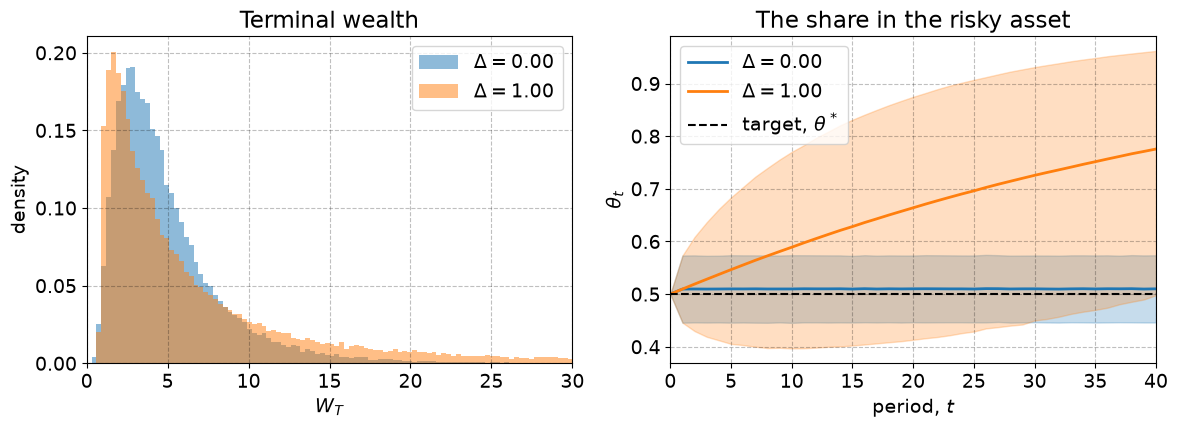

In [6]:
def plot_two_rules(models):

    fig = plt.figure(figsize=(12,4.5))

    # a. the distribution of terminal wealth
    ax = fig.add_subplot(1,2,1)
    for i,(Delta,m) in enumerate(models.items()):
        ax.hist(m.sim.W[:,-1],bins=np.linspace(0,30,101),density=True,color=colors[i],alpha=0.50,
                label=f'$\\Delta = {Delta:.2f}$')
    ax.set_title('Terminal wealth')
    ax.set_xlabel('$W_T$')
    ax.set_xlim(0,30)
    ax.set_ylabel('density')
    ax.legend()

    # b. the share in the risky asset over time
    ax = fig.add_subplot(1,2,2)
    t = np.arange(models[0.0].par.T+1)
    for i,(Delta,m) in enumerate(models.items()):
        ax.fill_between(t,np.percentile(m.sim.theta,10,axis=0),np.percentile(m.sim.theta,90,axis=0),
                        color=colors[i],alpha=0.25)
        ax.plot(t,np.mean(m.sim.theta,axis=0),lw=2,color=colors[i],label=f'$\\Delta = {Delta:.2f}$')
    ax.axhline(models[0.0].par.theta_star,ls='--',lw=1.5,color='black',label='target, $\\theta^*$')
    ax.set_title('The share in the risky asset')
    ax.set_xlabel('period, $t$')
    ax.set_ylabel(r'$\theta_t$')
    ax.set_xlim(0,models[0.0].par.T)
    ax.legend()

    fig.tight_layout()
    plt.show()

plot_two_rules(models)

The simulator loops over the $T$ periods, since period $t+1$ depends on period
$t$, but it never loops over the $N$ portfolios, which are independent of each
other and are handled in one array operation per period. It is tested on two
cases where the answer is known in advance: with $\Delta = 1$ and $\tau = 0$ the
portfolio is never traded and must give the same terminal wealth as buying and
holding, and with $\Delta = 0$ and $\tau = 0$ it must give a portfolio with
fixed weights. Both hold to thirteen decimals.

The two rules are simulated on the same drawn returns, so the differences below
come from the rule alone and not from luck.

The number of trades is 39 and not 40 under $\Delta = 0$. The investor starts
exactly at the target, $\theta_0 = \theta^*$, and the band is left only when
$|\theta_t - \theta^*| > \Delta$ holds strictly, so nothing is traded in period
0. From period 1 onwards the share always differs from the target and the
portfolio is traded in every single period. Under $\Delta = 1$ nothing is ever
traded, since $\theta_t$ lies between 0 and 1 and can never be more than 0.5
away from the target.

The average distance to the target is 0.039 under $\Delta = 0$ and 0.191 under
$\Delta = 1$, five times as large. Under $\Delta = 0$ the distance is only the
drift accumulated within a single period, since the portfolio is reset at the
start of the next one.

Never trading gives a much higher mean terminal wealth, 8.98 against 5.04, but
almost the same median, 4.45 against 4.08. The mean is pulled up by a thin right
tail of portfolios where the risky asset did well early, came to dominate the
portfolio, and then kept compounding. The 10th percentile moves the other way:
1.49 against 1.79. Never trading is better in the good states and worse in the
bad ones.

Expected utility ranks the two rules in the opposite order of the mean:
$-0.0678$ under $\Delta = 0$ against $-0.0767$ under $\Delta = 1$, so
rebalancing every period is the better rule. With $\gamma = 3$ the investor
dislikes low outcomes strongly, and the right tail that lifts the mean is worth
little to her. This is why the mean of $W_T$ on its own is a poor way to rank
the rules.

Panel i) of the figure shows the two distributions of terminal wealth, cut off
at 30 for readability; 0.1 percent of the $\Delta = 0$ portfolios and 5 percent
of the $\Delta = 1$ portfolios end above that. Panel ii) answers the last
question. When the portfolio is never traded, $\theta_t$ drifts upwards, from
0.50 to 0.78 on average over the 40 periods. The reason is that the risky asset
grows faster than the safe one in expectation, so its share of wealth rises on
its own. The drift does not settle down, and the band between the 10th and the
90th percentile widens as well, reaching 0.50 to 0.96 in the final period: after
40 years without trading, almost a third of the portfolios hold more than 90
percent in the risky asset. Under $\Delta = 0$ the mean stays flat at the target
and the band stays narrow throughout.